# PISA ML

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import prince
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [33]:
df = pd.read_csv('../data/01_pisa_preprocessed.csv')
print(f'Dataset cargado: {df.shape}')
df.head()

Dataset cargado: (29493, 30)


,id_centro,id_alumno,genero,dias_perdidos,llegadas_tarde,clases_saltadas,siento_excluido,hago_amigos,me_siento_parte,acoso_escolar,...,ansiedad_mat,educ_madre,educ_padre,escs,peso_muestral,rendimiento_mat,rendimiento_lec,rendimiento_cie,rendimiento,en_riesgo
0,72400658.0,72400003.0,2.0,1.0,1.0,3.0,4.0,1.0,1.0,1.0,...,-0.4577,9.0,9.0,0.6927,8.35724,494.8669,537.5307,522.2897,518.229100,0
1,72400761.0,72400007.0,1.0,2.0,2.0,2.0,4.0,97.0,2.0,1.0,...,0.6566,1.0,3.0,-1.7296,4.76191,372.5356,424.7139,349.9696,382.406367,1
2,72400784.0,72400010.0,1.0,1.0,1.0,2.0,4.0,2.0,1.0,1.0,...,0.4067,9.0,9.0,1.3153,29.87755,485.6010,497.4628,494.6975,492.587100,0
3,72400031.0,72400011.0,2.0,1.0,1.0,2.0,4.0,1.0,1.0,1.0,...,2.5429,10.0,2.0,-0.2449,4.98567,432.8490,323.1210,395.8614,383.943800,1
4,72400850.0,72400012.0,1.0,1.0,1.0,1.0,97.0,2.0,1.0,2.0,...,1.4278,3.0,7.0,-0.3402,51.72765,452.9222,518.1177,497.2441,489.428000,0


In [34]:
df.stb.missing()

,missing,total,percent
id_centro,0,29493,0.0
id_alumno,0,29493,0.0
genero,0,29493,0.0
dias_perdidos,0,29493,0.0
llegadas_tarde,0,29493,0.0
clases_saltadas,0,29493,0.0
siento_excluido,0,29493,0.0
hago_amigos,0,29493,0.0
me_siento_parte,0,29493,0.0
acoso_escolar,0,29493,0.0


In [ ]:
# Mapeos de valores por variable (usando los metadatos)
mapeos = {
    "genero": {
        1.0: "Female", 2.0: "Male",
        5.0: "Valid Skip", 7.0: "Not Applicable",
        8.0: "Invalid", 9.0: "No Response"
    },
    "repetidor": {
        0.0: "Never repeated", 1.0: "Repeated at least once",
        5.0: "Valid Skip", 7.0: "Not Applicable",
        8.0: "Invalid", 9.0: "No Response"
    },
    "estatus_migratorio": {
        1.0: "Native", 2.0: "Second-Generation",
        3.0: "First-Generation", 5.0: "Valid Skip",
        7.0: "Not Applicable", 8.0: "Invalid", 9.0: "No Response"
    },
    "expectativa_isced": {
        1.0: "< ISCED 2", 2.0: "ISCED 2", 3.0: "ISCED 3.3",
        4.0: "ISCED 3.4", 5.0: "ISCED 4", 6.0: "ISCED 5",
        7.0: "ISCED 6", 8.0: "ISCED 7", 9.0: "ISCED 8",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "educ_madre": {
        1.0: "< ISCED 1", 2.0: "ISCED 1", 3.0: "ISCED 2",
        4.0: "ISCED 3.3", 5.0: "ISCED 3.4", 6.0: "ISCED 4",
        7.0: "ISCED 5", 8.0: "ISCED 6", 9.0: "ISCED 7",
        10.0: "ISCED 8", 95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "educ_padre": {
        1.0: "< ISCED 1", 2.0: "ISCED 1", 3.0: "ISCED 2",
        4.0: "ISCED 3.3", 5.0: "ISCED 3.4", 6.0: "ISCED 4",
        7.0: "ISCED 5", 8.0: "ISCED 6", 9.0: "ISCED 7",
        10.0: "ISCED 8", 95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "siento_excluido": {
        1.0: "Strongly agree", 2.0: "Agree",
        3.0: "Disagree", 4.0: "Strongly disagree",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "hago_amigos": {
        1.0: "Strongly agree", 2.0: "Agree",
        3.0: "Disagree", 4.0: "Strongly disagree",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "me_siento_parte": {
        1.0: "Strongly agree", 2.0: "Agree",
        3.0: "Disagree", 4.0: "Strongly disagree",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "acoso_escolar": {
        1.0: "Never or almost never", 2.0: "A few times a year",
        3.0: "A few times a month", 4.0: "Once a week or more",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "dias_perdidos": {
        1.0: "Never", 2.0: "One or two times",
        3.0: "Three or four times", 4.0: "Five or more times",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "llegadas_tarde": {
        1.0: "Never", 2.0: "One or two times",
        3.0: "Three or four times", 4.0: "Five or more times",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
    "clases_saltadas": {
        1.0: "Never", 2.0: "One or two times",
        3.0: "Three or four times", 4.0: "Five or more times",
        95.0: "Valid Skip", 97.0: "Not Applicable",
        98.0: "Invalid", 99.0: "No Response"
    },
}

# mapeos
df_cat = df.copy()
for col, mapeo in mapeos.items():
    if col in df_cat.columns:
        df_cat[col] = df_cat[col].map(mapeo)

In [36]:
#variable binaria riesgo de abandono
df_cat["en_riesgo"] = df_cat["en_riesgo"].map({
    0: "Sin riesgo",
    1: "En riesgo"
})

# Crear variable binaria: nacido en España vs fuera
df_cat["origen"] = df_cat["pais_nac_alumno"].apply(
    lambda x: "España" if x == "072400" else "Extranjero"
)

# variable categorica a partir de numérica
# escs: nivel socioeconómico
df_cat["escs_cat"] = pd.cut(
    df_cat["escs"],
    bins=[-np.inf, -1, 0, 1, np.inf],  # cubre todo el rango
    labels=["Muy bajo", "Bajo", "Medio", "Alto"]
)
# pertenencia: sentido de pertenencia escolar
df_cat["pertenencia_cat"] = pd.cut(
    df_cat["pertenencia"],
    bins=3,
    labels=["Baja", "Media", "Alta"]
)
# ansiedad_mat: ansiedad relacionada con las matemáticas
df_cat["ansiedad_cat"] = pd.cut(
    df_cat["ansiedad_mat"],
    bins=3,
    labels=["Baja", "Media", "Alta"]
)

# curso: años de retraso o adelanto escolar
df_cat["curso"] = df_cat["curso"].map({
     0.0: "Curso normal",
    -1.0: "1 año de retraso",
    -2.0: "2 años de retraso",
    -3.0: "3 años de retraso",
     1.0: "1 año adelantado",
     2.0: "2 años adelantado"
})

In [ ]:
vars_mca = [
    # Socioeconómico
    "escs_cat", "educ_madre", "educ_padre",
    # Origen
    "estatus_migratorio",
    # Trayectoria
    "repetidor", "curso",
    # Motivación y salud
    "pertenencia_cat", "ansiedad_cat",
    # Expectativas
    "expectativa_isced",
    # Clima escolar
    "siento_excluido", "hago_amigos", "me_siento_parte",
    "acoso_escolar",
    # Absentismo
    "dias_perdidos", "llegadas_tarde", "clases_saltadas",
    # Perfil
    "genero",
]

# comprobaciòn nulos
print(df_cat[vars_mca].isnull().sum())

escs_cat              0
educ_madre            0
educ_padre            0
estatus_migratorio    0
repetidor             0
curso                 0
pertenencia_cat       0
ansiedad_cat          0
expectativa_isced     0
siento_excluido       0
hago_amigos           0
me_siento_parte       0
acoso_escolar         0
dias_perdidos         0
llegadas_tarde        0
clases_saltadas       0
genero                0
dtype: int64


In [38]:
df_cat.head()

,id_centro,id_alumno,genero,dias_perdidos,llegadas_tarde,clases_saltadas,siento_excluido,hago_amigos,me_siento_parte,acoso_escolar,...,peso_muestral,rendimiento_mat,rendimiento_lec,rendimiento_cie,rendimiento,en_riesgo,origen,escs_cat,pertenencia_cat,ansiedad_cat
0,72400658.0,72400003.0,Male,Never,Never,Three or four times,Strongly disagree,Strongly agree,Strongly agree,Never or almost never,...,8.35724,494.8669,537.5307,522.2897,518.229100,Sin riesgo,Extranjero,Medio,Baja,Baja
1,72400761.0,72400007.0,Female,One or two times,One or two times,One or two times,Strongly disagree,Not Applicable,Agree,Never or almost never,...,4.76191,372.5356,424.7139,349.9696,382.406367,En riesgo,Extranjero,Muy bajo,Baja,Baja
2,72400784.0,72400010.0,Female,Never,Never,One or two times,Strongly disagree,Agree,Strongly agree,Never or almost never,...,29.87755,485.6010,497.4628,494.6975,492.587100,Sin riesgo,Extranjero,Alto,Baja,Baja
3,72400031.0,72400011.0,Male,Never,Never,One or two times,Strongly disagree,Strongly agree,Strongly agree,Never or almost never,...,4.98567,432.8490,323.1210,395.8614,383.943800,En riesgo,Extranjero,Bajo,Baja,Baja
4,72400850.0,72400012.0,Female,Never,Never,Never,Not Applicable,Agree,Strongly agree,A few times a year,...,51.72765,452.9222,518.1177,497.2441,489.428000,Sin riesgo,Extranjero,Bajo,Baja,Baja


## MCA 

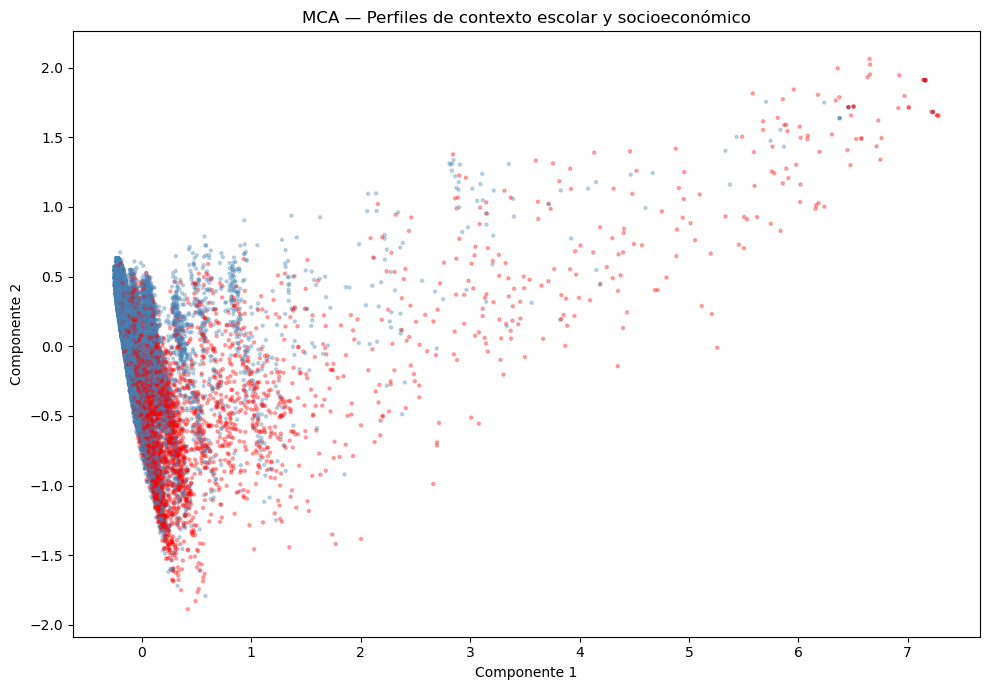

In [54]:
mca = prince.MCA(
    n_components=2,
    random_state=42
)

# Todas las variables deben ser string
df_mca = df_cat[vars_mca].astype(str)

# Ajustar y transformar
mca.fit(df_mca)
coords = mca.transform(df_mca)

# Añadir coordenadas al DataFrame
df_cat["mca_1"] = coords[0].values
df_cat["mca_2"] = coords[1].values

colores = df_cat["en_riesgo"].map({
    "En riesgo": "red",
    "Sin riesgo": "steelblue"
})

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    df_cat["mca_1"],
    df_cat["mca_2"],
    c=colores,
    alpha=0.3,
    s=5
)

ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_title("MCA — Perfiles de contexto escolar y socioeconómico")

plt.tight_layout()
plt.show()

In [56]:
df_mca_export = df_cat[["escs", "repetidor", "estatus_migratorio", "genero", "en_riesgo"]].copy()
df_mca_export["mca_1"] = df_cat["mca_1"].values
df_mca_export["mca_2"] = df_cat["mca_2"].values

df_mca_export.to_csv("../data/01_pisa_mca.csv", index=False)

Se observa del resultado del MCA aplicado sobre las variables del alumnado español, sin incluir medidas de rendimiento académico, ni si el alumnado es considerado de riesgo o no por su rendimiento. Cada punto corresponte a un alumno, posicionamos por perfiles de similitud. El color azul se ha utilizado para alumnos "sin riesgo" y el rojo "alumnos en riesgo".

El gráfico revela 3 zonas principales, de izquierda a derecha:
- Zona 1: El cluster maś denso donde se concentra la mayoría del alumnado con perfiles parecidos. Aquí conviven puntos azules y rojos, lo que indica que alumnado con perfil similar también puede ser perfil de riesgo. 
- Zona 2: Conforme el componente 1 va aumentando, los valores se vuelven más atípicos y la proporción de puntos rojos frente a azules empieza a crecer. Aquí los perfiles de riesgo se alejan de la norma y la proporción de alumnos en riesgo aumenta progresivamente. 
- Zona 3: En el extremo derecho, aquí ya empiezan a aparecer casos aislados, casi de forma exclusiva hay puntos rojos. Se entiende esta zona como alumnado con perfiles peculiares, lejos de la norma. 

En conclusión, el hecho de que haya una zona densa con puntos rojos concentrados y parcialmente solapada con una nube de puntos azules, indica que existe un perfil de contexto asociado al riesgo de abandono, aunque la gran mayoría del alumnado en riesgo no presenta características claramente diferenciadas del resto, lo que dificulta su detección temprana.

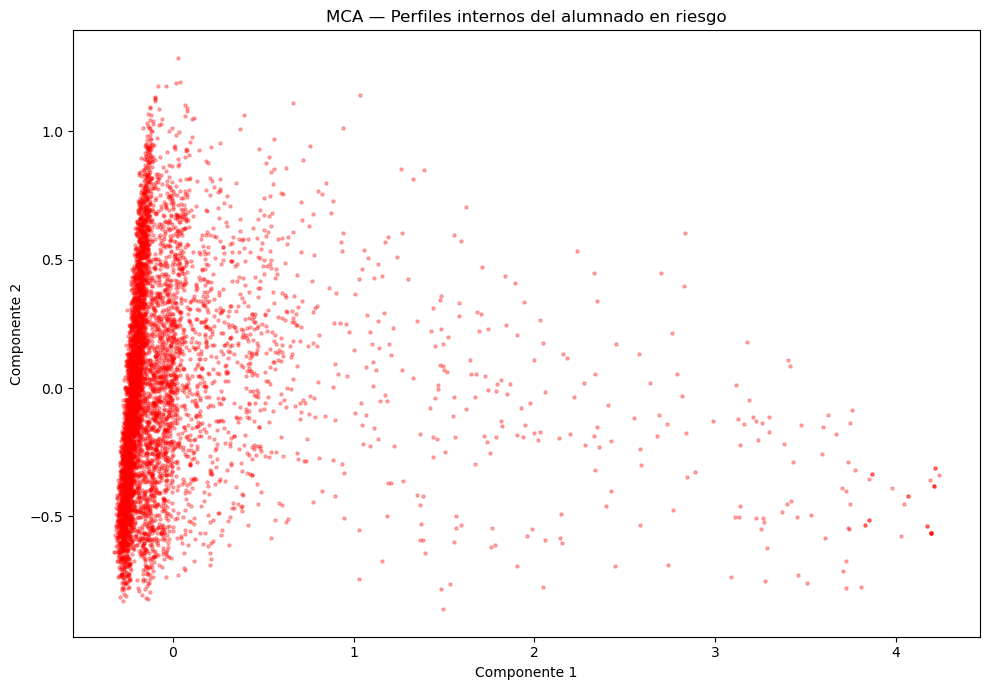

In [41]:
df_cat_riesgo = df_cat[df_cat["en_riesgo"] == "En riesgo"]
df_mca_riesgo = df_cat_riesgo[vars_mca].astype(str)

mca_riesgo = prince.MCA(
    n_components=2,
    random_state=42
)
mca_riesgo.fit(df_mca_riesgo)
coords_riesgo = mca_riesgo.transform(df_mca_riesgo)

df_cat_riesgo["mca_1"] = coords_riesgo[0].values
df_cat_riesgo["mca_2"] = coords_riesgo[1].values

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    df_cat_riesgo["mca_1"],
    df_cat_riesgo["mca_2"],
    alpha=0.3,
    s=5,
    color="red"
)
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_title("MCA — Perfiles internos del alumnado en riesgo")
plt.tight_layout()
plt.show()


Realizada la misma técnica pero filtrado por perfiles "En riesgo" para intentar observar agrupaciones dentro de este conjunto, se ve que el alumnado en riesgo no responde a un perfil único ni a varios perfiles bien definidos. Más bien existe un gradiente — desde alumnos en riesgo con perfiles relativamente típicos (cluster denso izquierda) hasta casos con acumulación extrema de factores desfavorables (cola derecha).

Esto podría revelar que es difícil establecer arquetipos de alumno en riesgo. 

# Regresión Logística

In [42]:
df.head()

,id_centro,id_alumno,genero,dias_perdidos,llegadas_tarde,clases_saltadas,siento_excluido,hago_amigos,me_siento_parte,acoso_escolar,...,ansiedad_mat,educ_madre,educ_padre,escs,peso_muestral,rendimiento_mat,rendimiento_lec,rendimiento_cie,rendimiento,en_riesgo
0,72400658.0,72400003.0,2.0,1.0,1.0,3.0,4.0,1.0,1.0,1.0,...,-0.4577,9.0,9.0,0.6927,8.35724,494.8669,537.5307,522.2897,518.229100,0
1,72400761.0,72400007.0,1.0,2.0,2.0,2.0,4.0,97.0,2.0,1.0,...,0.6566,1.0,3.0,-1.7296,4.76191,372.5356,424.7139,349.9696,382.406367,1
2,72400784.0,72400010.0,1.0,1.0,1.0,2.0,4.0,2.0,1.0,1.0,...,0.4067,9.0,9.0,1.3153,29.87755,485.6010,497.4628,494.6975,492.587100,0
3,72400031.0,72400011.0,2.0,1.0,1.0,2.0,4.0,1.0,1.0,1.0,...,2.5429,10.0,2.0,-0.2449,4.98567,432.8490,323.1210,395.8614,383.943800,1
4,72400850.0,72400012.0,1.0,1.0,1.0,1.0,97.0,2.0,1.0,2.0,...,1.4278,3.0,7.0,-0.3402,51.72765,452.9222,518.1177,497.2441,489.428000,0


In [43]:
df_lr = df.copy()
vars_modelo = [
    "escs", "educ_madre", "educ_padre",
    "estatus_migratorio", "repetidor", "curso",
    "pertenencia", "ansiedad_mat",
    "expectativa_isced", "siento_excluido",
    "hago_amigos", "me_siento_parte", "acoso_escolar",
    "dias_perdidos", "llegadas_tarde", "clases_saltadas",
    "genero"
]
df_lr = df_lr[vars_modelo + ["en_riesgo"]]
df_lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 29493 entries, 0 to 29492
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   escs                29493 non-null  float64
 1   educ_madre          29493 non-null  float64
 2   educ_padre          29493 non-null  float64
 3   estatus_migratorio  29493 non-null  float64
 4   repetidor           29493 non-null  float64
 5   curso               29493 non-null  float64
 6   pertenencia         29493 non-null  float64
 7   ansiedad_mat        29493 non-null  float64
 8   expectativa_isced   29493 non-null  float64
 9   siento_excluido     29493 non-null  float64
 10  hago_amigos         29493 non-null  float64
 11  me_siento_parte     29493 non-null  float64
 12  acoso_escolar       29493 non-null  float64
 13  dias_perdidos       29493 non-null  float64
 14  llegadas_tarde      29493 non-null  float64
 15  clases_saltadas     29493 non-null  float64
 16  genero         

**Por qué se eligen las siguientes columnas:**
- `escs`: el predictor más robusto en toda la literatura PISA.
- `educ_madre`, `educ_padre`: complementa a `escs`con información sobre el nivel educativo de los padres. 
- `estatus_migratorio`: colectivo con riesgo especialmente alto.
- `repetidor`, `curso`: trayectoria educativa previa. 
- `pertenencia`, `ansiedad_mat`: factores psicosociales. 
- `expectativa_isced`: las expectativas del propio alumno sobre su futuro educativo.
- `siento_excluido`, `hago_amigos`, `me_siento_parte`: clima escolar e integración social.
- `acoso_escolar`: factor de riesgo psicosocial directo.
- `dias_perdidos`, `llegadas_tarde`, `clases_saltadas` -> `absentismo`. Es el paso previo al abandono.
- `genero`: los factores de riesgo no son los mismos para chicos y chicas según la literatura PISA.

**Por qué se eliminan als siguientes columnas:**
- `rendimiento_mat/lec/cie/rendimiento`: derivan directamente de `en_riesgo`.
- `id_centro`, `id_alumno`: no tienen valor predictivo.
- `peso_muestral`: no una característica del alumno.
- `edad`: en España, los alumnos que hacen la prueba tienen la misma edad
- `pais_nac_alumno/madre/padre`: demasiados valores únicos, se utiliza `estatus_migratorio`. 
- `lengua_casa` → también resumida por `estatus_migratorio`.


In [44]:
X = df_lr.drop(columns=["en_riesgo"])
y = df_lr["en_riesgo"]

print(f"X shape: {X.shape}")
print(f"Distribución target:\n{y.value_counts()}")



X shape: (29493, 17)
Distribución target:
en_riesgo
0    23342
1     6151
Name: count, dtype: int64


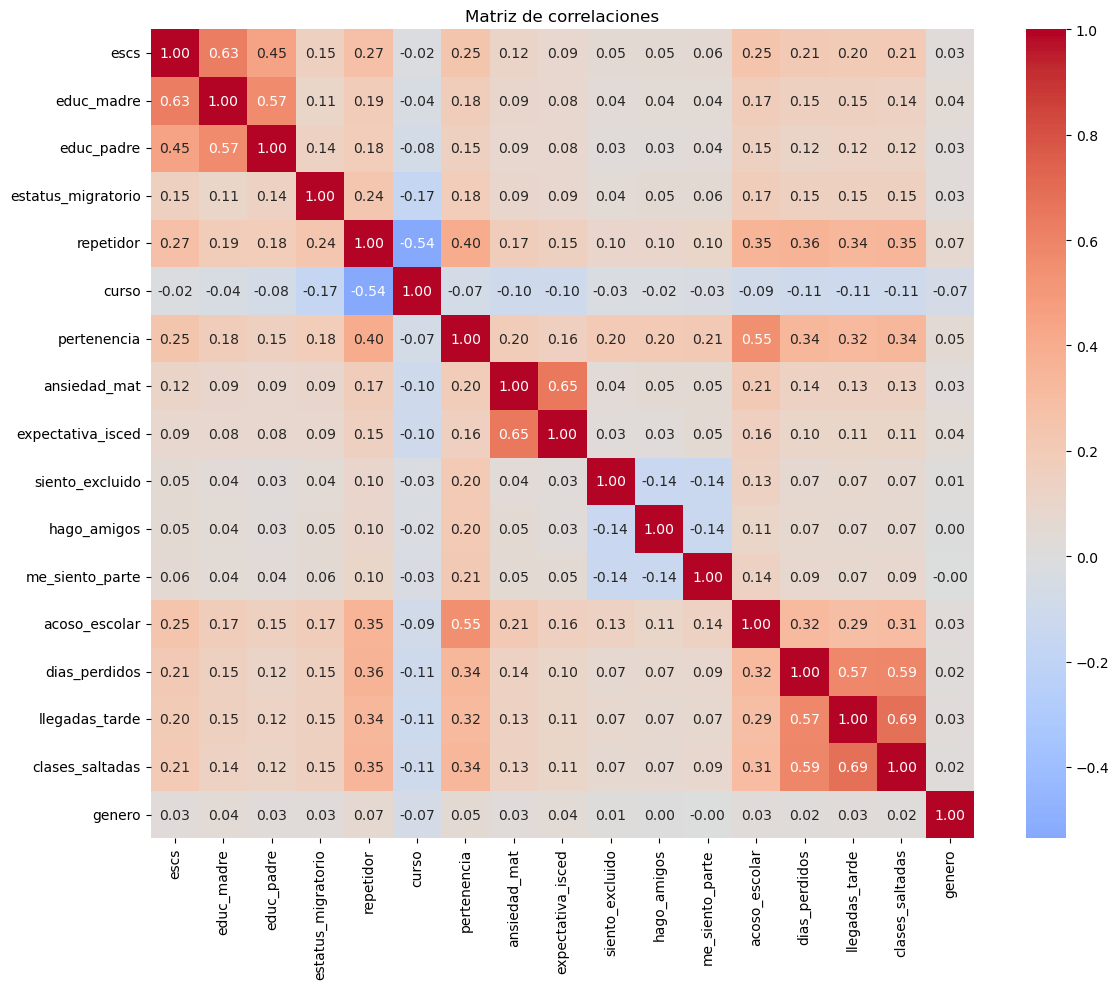

In [45]:
corr = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

Dada la correción fuerte (0.69, 0.59 y 0.57) entre `llegadas_tarde`, `clases_saltadas` y `dias_perdidos` y que miden lo mismo desde diferentes puntos de vistas, para evitar la multicolinealidad se genera una variable nueva `absentismo`. 

In [46]:
X["absentismo"] = X["dias_perdidos"] + X["llegadas_tarde"] + X["clases_saltadas"]
X = X.drop(columns=["dias_perdidos", "llegadas_tarde", "clases_saltadas"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Distribución train:\n{y_train.value_counts()}")

Train: (23594, 15)
Test: (5899, 15)
Distribución train:
en_riesgo
0    18673
1     4921
Name: count, dtype: int64


In [ ]:
# regresión logística
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10],         
    "lr__l1_ratio": [0, 1],              
    "lr__solver": ["liblinear", "saga"] 
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=0
)

grid_lr.fit(X_train, y_train)



y_pred_lr_best = grid_lr.predict(X_test)
print("=== REGRESIÓN LOGÍSTICA ===")
print(f"Mejores parámetros: {grid_lr.best_params_}")
print(classification_report(y_test, y_pred_lr_best))

=== REGRESIÓN LOGÍSTICA ===
Mejores parámetros: {'lr__C': 1, 'lr__l1_ratio': 0, 'lr__solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      4669
           1       0.50      0.60      0.54      1230

    accuracy                           0.79      5899
   macro avg       0.69      0.72      0.70      5899
weighted avg       0.81      0.79      0.80      5899



In [49]:
print(f"Variables en el modelo: {len(X_train.columns)}")
print(X_train.columns.tolist())

Variables en el modelo: 15
['escs', 'educ_madre', 'educ_padre', 'estatus_migratorio', 'repetidor', 'curso', 'pertenencia', 'ansiedad_mat', 'expectativa_isced', 'siento_excluido', 'hago_amigos', 'me_siento_parte', 'acoso_escolar', 'genero', 'absentismo']


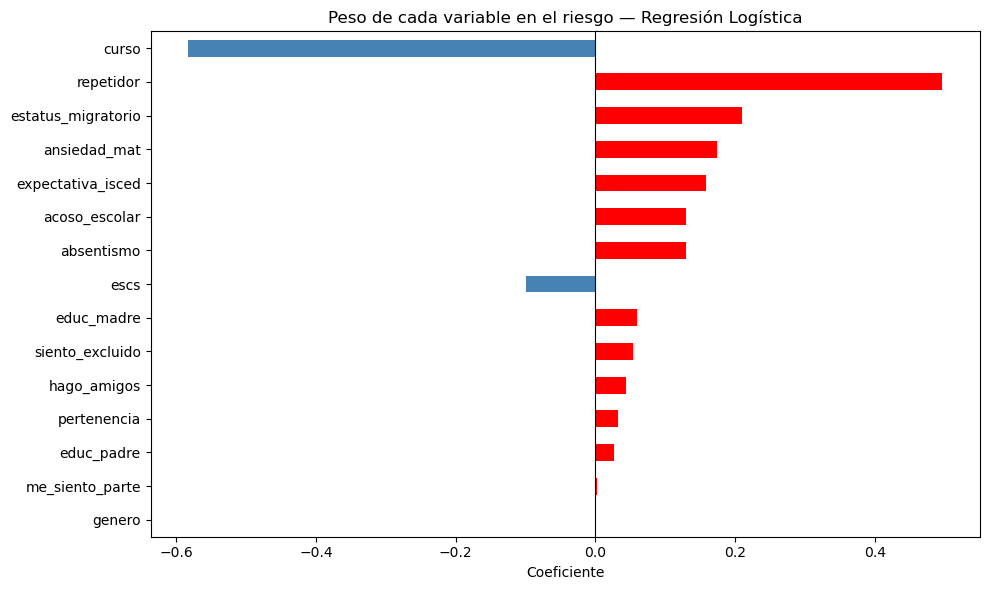

In [50]:
# Extraer coeficientes del pipeline
coefs = pd.Series(
    grid_lr.best_estimator_.named_steps["lr"].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
coefs.plot(kind="barh", color=["red" if c > 0 else "steelblue" for c in coefs])
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente")
plt.title("Peso de cada variable en el riesgo — Regresión Logística")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [57]:
# Random Forest
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="recall",  # optimizar recall
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Mejores parámetros: {grid.best_params_}")
print(classification_report(y_test, y_pred_best))


=== RANDOM FOREST ===
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      4669
           1       0.54      0.64      0.59      1230

    accuracy                           0.81      5899
   macro avg       0.72      0.75      0.73      5899
weighted avg       0.83      0.81      0.82      5899



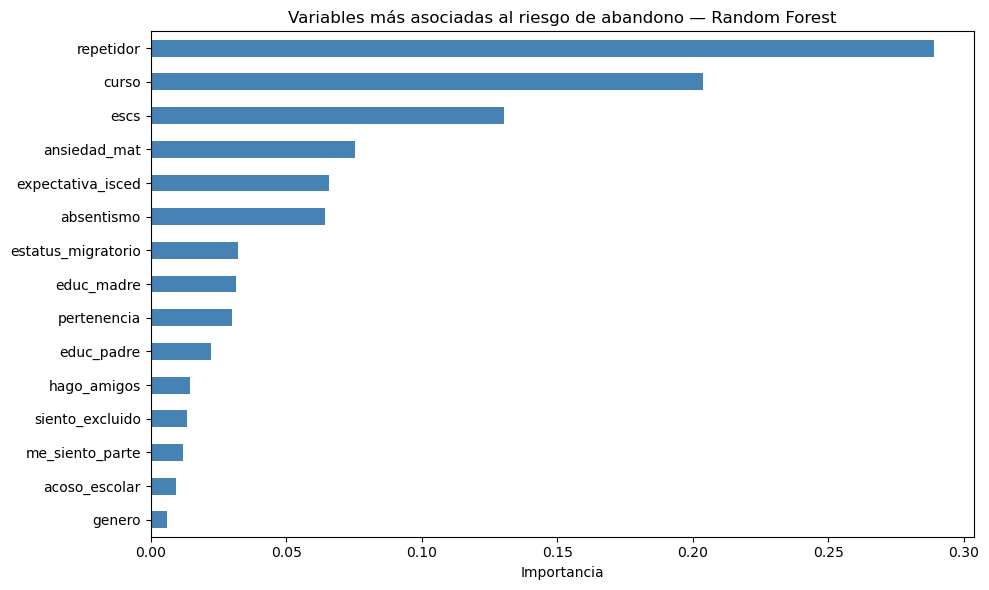

In [ ]:
importancias = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.plot(kind="barh", color="steelblue")
plt.xlabel("Importancia")
plt.title("Variables más asociadas al riesgo de abandono — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
importancias.reset_index().rename(columns={"index": "variable", 0: "importancia"}).to_csv("../data/01_pisa_importancia_rf.csv", index=False)

El random forest alcanza un accuracy global del 81%, con un recall de 64% para la clase "en_riesgo". De cada 100 alumnos en riesgo, detecta 64; no obstante. La preción del 54% en esa misma clase indica que algo menos de la mitad de lo que inicialmente se identican como "en_riesgo" no están, pero como se trata de una herramienta con la idea de detectar de forma temprana, los falsos positivos no son un problema. 

En cuanto a las variables con poder predictivo, las tres dominantes son **repetidor**, **curso** y nivel socioeconómico **escs**. En segundo nivel, aparecen **ansiedad a las matemáticas**, **expectativas del propio nivel educativo** y **absentismo**. 